# Data Science Project 3 — Unsupervised Learning

## Customer Segmentation

### Objective
The objective of this project is to apply unsupervised learning techniques to discover hidden customer segments in retail data.

The project focuses on:
- Data preprocessing and feature engineering
- Principal Component Analysis (PCA) for dimensionality reduction
- K-Means clustering for customer segmentation
- Elbow Method for selecting the number of clusters
- Silhouette Score for validating cluster quality
- Business interpretation of the resulting customer personas

The final goal is to transform mathematical clusters into meaningful business insights and actionable customer personas.

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, dimensionality reduction, clustering, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

The retail dataset is loaded from the provided Excel file for further exploration and preprocessing.

In [2]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 3. Initial Dataset Inspection

Before applying machine learning techniques, the dataset is examined to understand its structure, dimensions, data types, and overall contents.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1200, 14)

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


## 4. Missing Values and Duplicate Records

Missing values and duplicate records are checked before modeling.

Missing values can affect preprocessing and machine learning algorithms, while duplicate records may introduce unnecessary repetition into the analysis.

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Duplicate Rows:", df.duplicated().sum())

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Total Duplicate Rows: 0


## 5. Statistical Summary

A statistical summary of the numerical variables is generated to understand their distributions, central tendencies, and ranges.

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1200,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
Quantity,1200.0,2.945833,1.0,2.0,3.0,4.0,5.0,1.407557
UnitPrice,1200.0,356.41275,11.39,186.0625,364.21,521.57,699.93,197.177146
ItemsInCart,1200.0,5.485,1.0,4.0,5.0,7.0,10.0,2.281983
TotalPrice,1200.0,1053.9683,11.39,410.52,823.615,1578.475,3456.4,819.856558


## 6. Categorical Feature Analysis

The unique categories and their frequencies are examined for the major categorical variables.
This helps identify suitable features for encoding before applying PCA and clustering.

In [6]:
categorical_columns = [
    'Product',
    'PaymentMethod',
    'OrderStatus',
    'CouponCode',
    'ReferralSource'
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- Product ---
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

--- OrderStatus ---
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

--- CouponCode ---
CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

--- ReferralSource ---
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


## 7. Customer-Level Structure

The CustomerID column is examined to determine whether the dataset contains repeated purchases from the same customers.

This is important because customer segmentation ideally relies on customer-level behavioral information.

In [7]:
print("Unique Customers:", df['CustomerID'].nunique())
print("Total Orders:", df['OrderID'].nunique())

customer_frequency = df['CustomerID'].value_counts()

print("\nCustomer Purchase Frequency:")
print(customer_frequency.value_counts().sort_index())

Unique Customers: 1189
Total Orders: 1200

Customer Purchase Frequency:
count
1    1178
2      11
Name: count, dtype: int64


## 8. Handling Missing Coupon Information

The CouponCode column contains missing values.

A missing coupon code can reasonably represent an order where no coupon was used. Therefore, instead of deleting these observations, missing values are replaced with the category `No Coupon`.

In [8]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

print(df['CouponCode'].value_counts())

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


## 9. Feature Relationship Check

TotalPrice is mathematically calculated from Quantity and UnitPrice.

Therefore, including all three variables in the clustering model would introduce redundant information. Quantity, UnitPrice, and ItemsInCart are retained as the primary numerical behavioral features, while TotalPrice is kept for later business interpretation.

In [9]:
calculated_total = df['Quantity'] * df['UnitPrice']

print(
    "Percentage of rows where TotalPrice = Quantity × UnitPrice:",
    np.mean(np.isclose(df['TotalPrice'], calculated_total)) * 100,
    "%"
)

Percentage of rows where TotalPrice = Quantity × UnitPrice: 100.0 %


## 10. Feature Selection

Identifiers such as OrderID, CustomerID, and TrackingNumber are excluded because they do not represent meaningful behavioral characteristics.

ShippingAddress is also excluded because it is a high-cardinality location field.

OrderStatus is excluded from the primary clustering model because it represents an order outcome rather than a stable purchasing characteristic.

The selected features focus on purchasing behavior, product preference, payment behavior, coupon usage, and acquisition source.

In [10]:
numerical_features = [
    'Quantity',
    'UnitPrice',
    'ItemsInCart'
]

categorical_features = [
    'Product',
    'PaymentMethod',
    'CouponCode',
    'ReferralSource'
]

selected_features = numerical_features + categorical_features

df[selected_features].head()

,Quantity,UnitPrice,ItemsInCart,Product,PaymentMethod,CouponCode,ReferralSource
0,5,570.62,7,Monitor,Debit Card,SAVE10,Instagram
1,2,151.35,3,Phone,Online,SAVE10,Referral
2,5,550.68,8,Tablet,Credit Card,FREESHIP,Email
3,1,273.19,5,Chair,Debit Card,SAVE10,Facebook
4,4,626.01,8,Printer,Online,SAVE10,Email


## 11. Data Preprocessing for PCA

PCA requires numerical input. Therefore, categorical variables are converted into numerical representations using One-Hot Encoding.

Numerical variables are standardized so that features with larger numerical scales do not dominate the analysis.

The resulting feature matrix will contain more dimensions than the original dataset because categorical variables are expanded into multiple binary features.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X = preprocessor.fit_transform(df[selected_features])

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (1200, 24)


## 12. Principal Component Analysis (PCA)

Principal Component Analysis is applied to reduce the dimensionality of the preprocessed feature matrix.

PCA transforms the original features into principal components that capture the maximum possible variance in fewer dimensions.

Three principal components are initially calculated so that the explained variance can be examined before selecting the visualization dimensions.

In [12]:
pca = PCA(n_components=3, random_state=42)

X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

print("\nCumulative Explained Variance:")
print(np.cumsum(explained_variance))

Explained Variance Ratio:
PC1: 0.2665
PC2: 0.1616
PC3: 0.0572

Cumulative Explained Variance:
[0.26652431 0.42811985 0.48534562]


## 13. PCA Visualization

The first two principal components are visualized to provide a two-dimensional representation of the high-dimensional feature space.

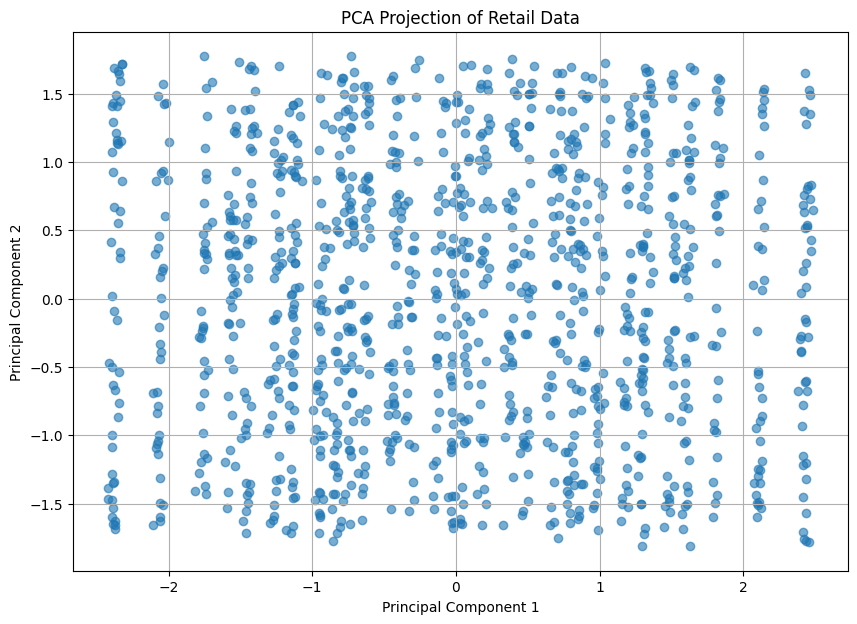

In [13]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Retail Data")
plt.grid(True)

plt.show()

## 14. Determining the Optimal Number of Clusters

K-Means clustering requires the number of clusters, K, to be specified in advance.

The Elbow Method is used to evaluate different values of K by measuring the within-cluster sum of squares, represented by inertia.

A sharp reduction in inertia followed by smaller improvements indicates a potential elbow point.

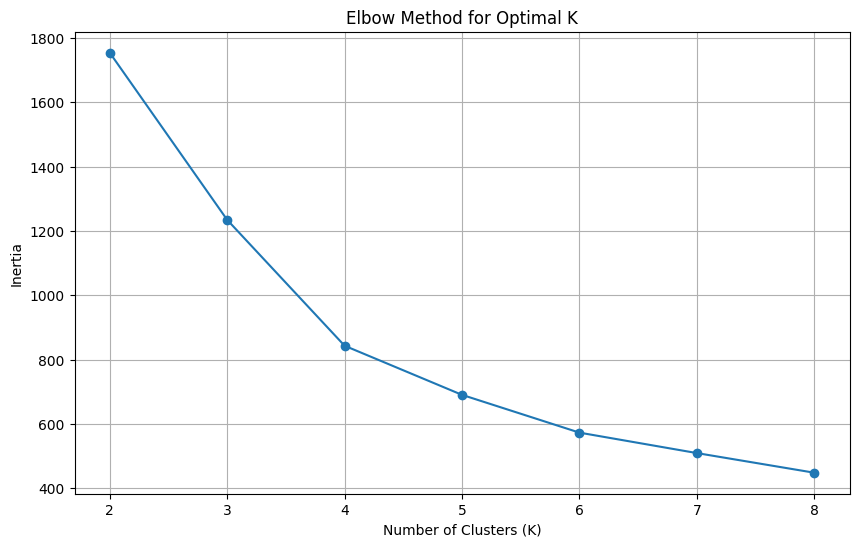

In [14]:
inertias = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca[:, :2])
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(K_range, inertias, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()

## 15. Silhouette Score Analysis

The Silhouette Score evaluates how well each observation fits within its assigned cluster compared with other clusters.

A higher Silhouette Score indicates better-defined and more separated clusters.

Silhouette Scores are calculated for multiple values of K and compared with the Elbow Method before selecting the final number of clusters.

In [15]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca[:, :2])

    score = silhouette_score(
        X_pca[:, :2],
        labels
    )

    silhouette_scores.append(score)

results = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})

results

,K,Inertia,Silhouette Score
0,2,1754.359242,0.391354
1,3,1234.771527,0.383120
2,4,843.387731,0.392350
3,5,690.714565,0.379079
4,6,573.278439,0.355880
5,7,509.716699,0.340192
6,8,448.659479,0.338544


## 16. Silhouette Score Comparison

The Silhouette Scores are visualized to compare the quality of clustering across different values of K.

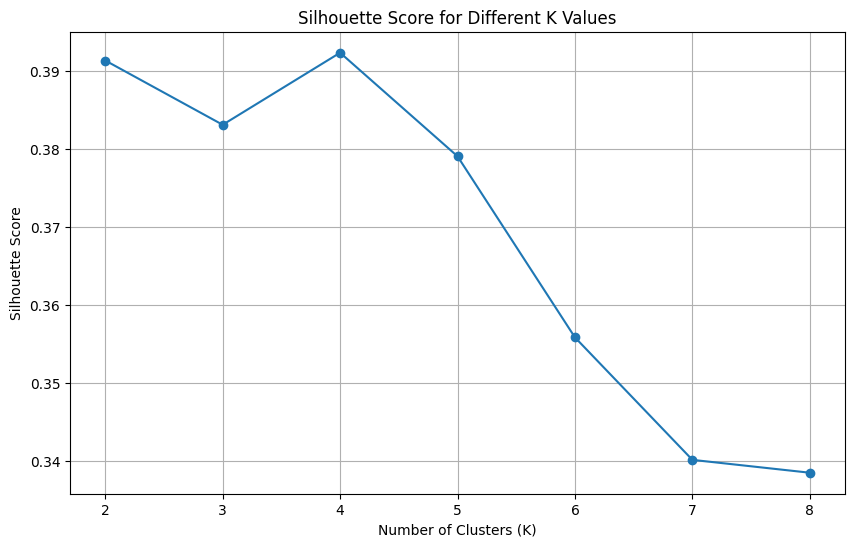

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    results['K'],
    results['Silhouette Score'],
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()

## 17. Selection of the Optimal Number of Clusters

Both the Elbow Method and Silhouette Score are used to determine the optimal number of clusters.

The Elbow Method shows a substantial reduction in inertia up to approximately K = 4, after which the improvement becomes more gradual.

The Silhouette Score reaches its highest value at K = 4, indicating that four clusters provide the best separation among the tested values.

Therefore, **K = 4 is selected as the optimal number of clusters for the K-Means model.**

## 18. Final K-Means Clustering Model

A final K-Means clustering model is trained using the selected value of K = 4.

The cluster labels are assigned to each observation based on its position in the PCA-reduced feature space.

In [17]:
optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_pca[:, :2])

df['Cluster'] = cluster_labels

print("Cluster labels assigned successfully.")

Cluster labels assigned successfully.


## 19. Cluster Distribution

The number of observations assigned to each cluster is examined to understand the distribution of the four customer segments.

Cluster
0    322
1    334
2    264
3    280
Name: count, dtype: int64


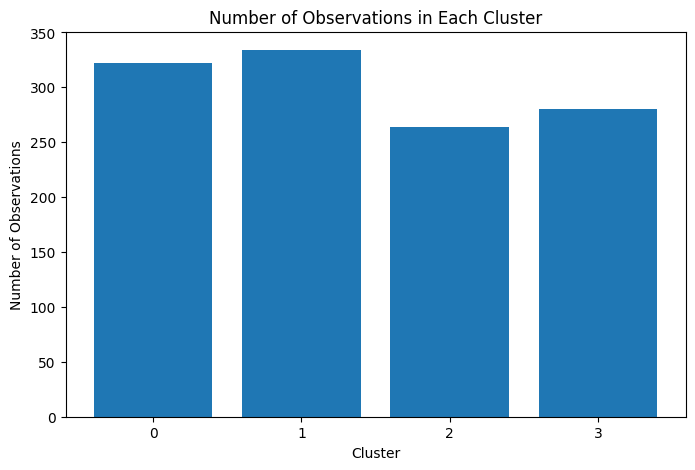

In [18]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print(cluster_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Observations")
plt.title("Number of Observations in Each Cluster")

plt.show()

## 20. Final Customer Segmentation Visualization

The four K-Means clusters are visualized using the first two principal components.

This visualization provides a two-dimensional representation of the segmentation obtained from the high-dimensional feature space.

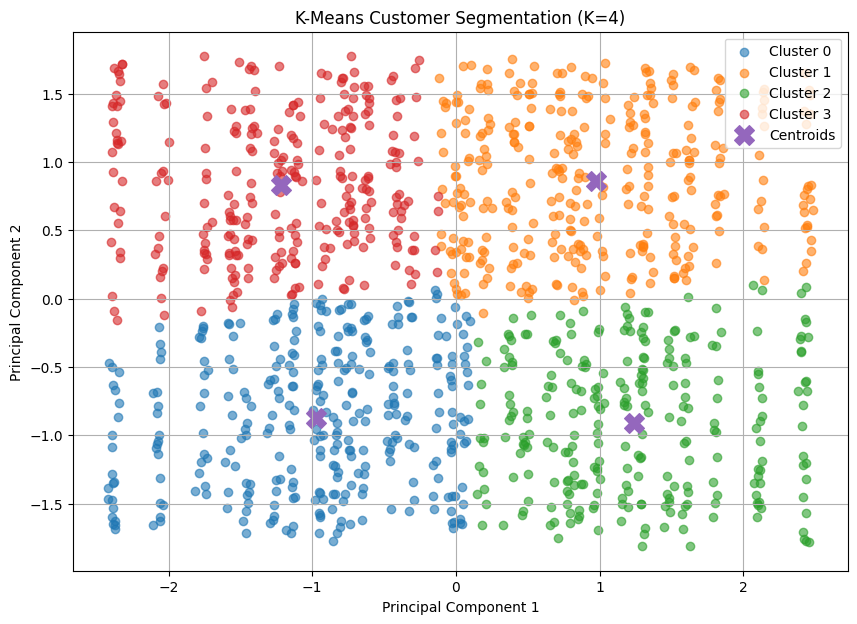

In [19]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = X_pca[df['Cluster'] == cluster]

    plt.scatter(
        cluster_data[:, 0],
        cluster_data[:, 1],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

centers = final_kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Segmentation (K=4)")
plt.legend()
plt.grid(True)

plt.show()

## 21. Cluster Profiling

To translate the mathematical clusters into meaningful business personas, the characteristics of each cluster are analyzed.

Numerical purchasing behavior is compared across clusters using average Quantity, UnitPrice, ItemsInCart, and TotalPrice.

In [20]:
cluster_profile = df.groupby('Cluster').agg(
    Customers=('CustomerID', 'nunique'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_UnitPrice=('UnitPrice', 'mean'),
    Avg_ItemsInCart=('ItemsInCart', 'mean'),
    Avg_TotalPrice=('TotalPrice', 'mean')
).round(2)

cluster_profile

,Customers,Avg_Quantity,Avg_UnitPrice,Avg_ItemsInCart,Avg_TotalPrice
Cluster,,,,,
0,321,1.93,182.37,4.03,365.92
1,333,3.94,529.16,6.97,2090.66
2,264,4.25,181.10,7.42,774.45
3,279,1.70,515.79,3.56,872.15


## 22. Product Preferences by Cluster

The distribution of products within each cluster is examined to identify differences in purchasing preferences between the segments.

In [21]:
product_by_cluster = pd.crosstab(
    df['Cluster'],
    df['Product'],
    normalize='index'
).round(3) * 100

product_by_cluster

Product,Chair,Desk,Laptop,Monitor,Phone,Printer,Tablet
Cluster,,,,,,,
0,11.2,15.8,14.3,13.7,13.7,16.1,15.2
1,17.4,12.9,15.3,14.1,10.2,16.2,14.1
2,16.7,17.4,14.0,13.3,11.0,15.2,12.5
3,14.3,10.7,13.9,13.2,17.5,12.5,17.9


## 23. Coupon Usage by Cluster

Coupon behavior is compared across clusters to determine whether particular segments are more likely to purchase using promotional discounts.

In [22]:
coupon_by_cluster = pd.crosstab(
    df['Cluster'],
    df['CouponCode'],
    normalize='index'
).round(3) * 100

coupon_by_cluster

CouponCode,FREESHIP,No Coupon,SAVE10,WINTER15
Cluster,,,,
0,24.5,25.5,24.2,25.8
1,26.0,24.9,24.0,25.1
2,23.1,29.2,24.2,23.5
3,30.7,23.9,22.9,22.5


## 24. Payment Preferences by Cluster

Payment methods are analyzed across the four clusters to identify differences in purchasing and payment behavior.

In [23]:
payment_by_cluster = pd.crosstab(
    df['Cluster'],
    df['PaymentMethod'],
    normalize='index'
).round(3) * 100

payment_by_cluster

PaymentMethod,Cash,Credit Card,Debit Card,Gift Card,Online
Cluster,,,,,
0,17.4,19.6,21.7,16.8,24.5
1,21.0,23.7,18.9,18.0,18.6
2,25.4,17.0,19.3,20.5,17.8
3,18.9,16.8,17.1,22.1,25.0


## 25. Referral Sources by Cluster

Referral sources are compared across clusters to determine whether different customer segments are associated with different acquisition channels.

In [24]:
referral_by_cluster = pd.crosstab(
    df['Cluster'],
    df['ReferralSource'],
    normalize='index'
).round(3) * 100

referral_by_cluster

ReferralSource,Email,Facebook,Google,Instagram,Referral
Cluster,,,,,
0,23.0,17.1,19.9,24.2,15.8
1,20.4,20.7,20.7,21.6,16.8
2,22.7,17.4,23.1,18.2,18.6
3,17.1,20.7,16.8,21.8,23.6


## 26. Business Persona Interpretation

The numerical and categorical characteristics of the four clusters are analyzed to translate the mathematical segmentation into actionable business personas.

The personas are based on purchasing quantity, product price, basket size, total spending, coupon behavior, payment preferences, and referral sources.

In [25]:
# Create a concise comparison table for the four clusters

persona_profile = cluster_profile.copy()

persona_profile['Persona'] = [
    'Budget / Low-Value Shoppers',
    'Premium High-Value Shoppers',
    'Bulk Value Shoppers',
    'Selective Premium Shoppers'
]

persona_profile = persona_profile[
    ['Persona', 'Customers', 'Avg_Quantity',
     'Avg_UnitPrice', 'Avg_ItemsInCart', 'Avg_TotalPrice']
]

persona_profile

,Persona,Customers,Avg_Quantity,Avg_UnitPrice,Avg_ItemsInCart,Avg_TotalPrice
Cluster,,,,,,
0,Budget / Low-Value Shoppers,321,1.93,182.37,4.03,365.92
1,Premium High-Value Shoppers,333,3.94,529.16,6.97,2090.66
2,Bulk Value Shoppers,264,4.25,181.10,7.42,774.45
3,Selective Premium Shoppers,279,1.70,515.79,3.56,872.15


### Cluster 0 — Budget / Low-Value Shoppers

Cluster 0 contains 322 observations and represents customers with relatively low purchasing intensity.

Key characteristics:
- Average quantity: 1.93
- Average unit price: 182.37
- Average items in cart: 4.03
- Average total price: 365.92

This cluster represents lower-value transactions involving fewer items and lower-priced products.

Business strategy:
- Promote affordable products and entry-level offerings.
- Use small discounts or free-shipping incentives to encourage additional purchases.
- Recommend complementary low-cost products to increase basket size.

### Cluster 1 — Premium High-Value Shoppers

Cluster 1 contains 334 observations and is the highest-value segment.

Key characteristics:
- Average quantity: 3.94
- Average unit price: 529.16
- Average items in cart: 6.97
- Average total price: 2090.66

This segment combines relatively high-priced products with larger quantities and larger baskets, resulting in the highest average spending among all four clusters.

Business strategy:
- Provide premium product recommendations.
- Introduce loyalty and VIP programs.
- Offer personalized recommendations for high-value products.
- Focus retention campaigns on this segment because of its high spending potential.

### Cluster 2 — Bulk Value Shoppers

Cluster 2 contains 264 observations and is characterized by high purchase quantities and large baskets despite relatively low product prices.

Key characteristics:
- Average quantity: 4.25
- Average unit price: 181.10
- Average items in cart: 7.42
- Average total price: 774.45

This segment purchases more items but tends to select lower-priced products. It also has the highest proportion of orders with no coupon usage.

Business strategy:
- Promote bundle offers and quantity-based discounts.
- Recommend related products to increase basket value.
- Use volume-based promotions rather than focusing exclusively on premium products.

### Cluster 3 — Selective Premium Shoppers

Cluster 3 contains 280 observations and is characterized by low purchasing quantity and basket size but relatively high-priced products.

Key characteristics:
- Average quantity: 1.70
- Average unit price: 515.79
- Average items in cart: 3.56
- Average total price: 872.15

This segment appears to make relatively selective purchases, choosing higher-priced products without purchasing large quantities.

Business strategy:
- Highlight premium product quality and features.
- Provide detailed product information and comparisons.
- Use targeted recommendations rather than large-volume promotions.
- Encourage complementary purchases to increase basket size.

## 27. Comparison of Customer Personas

The four customer personas are compared using their average quantity, unit price, basket size, and total spending.

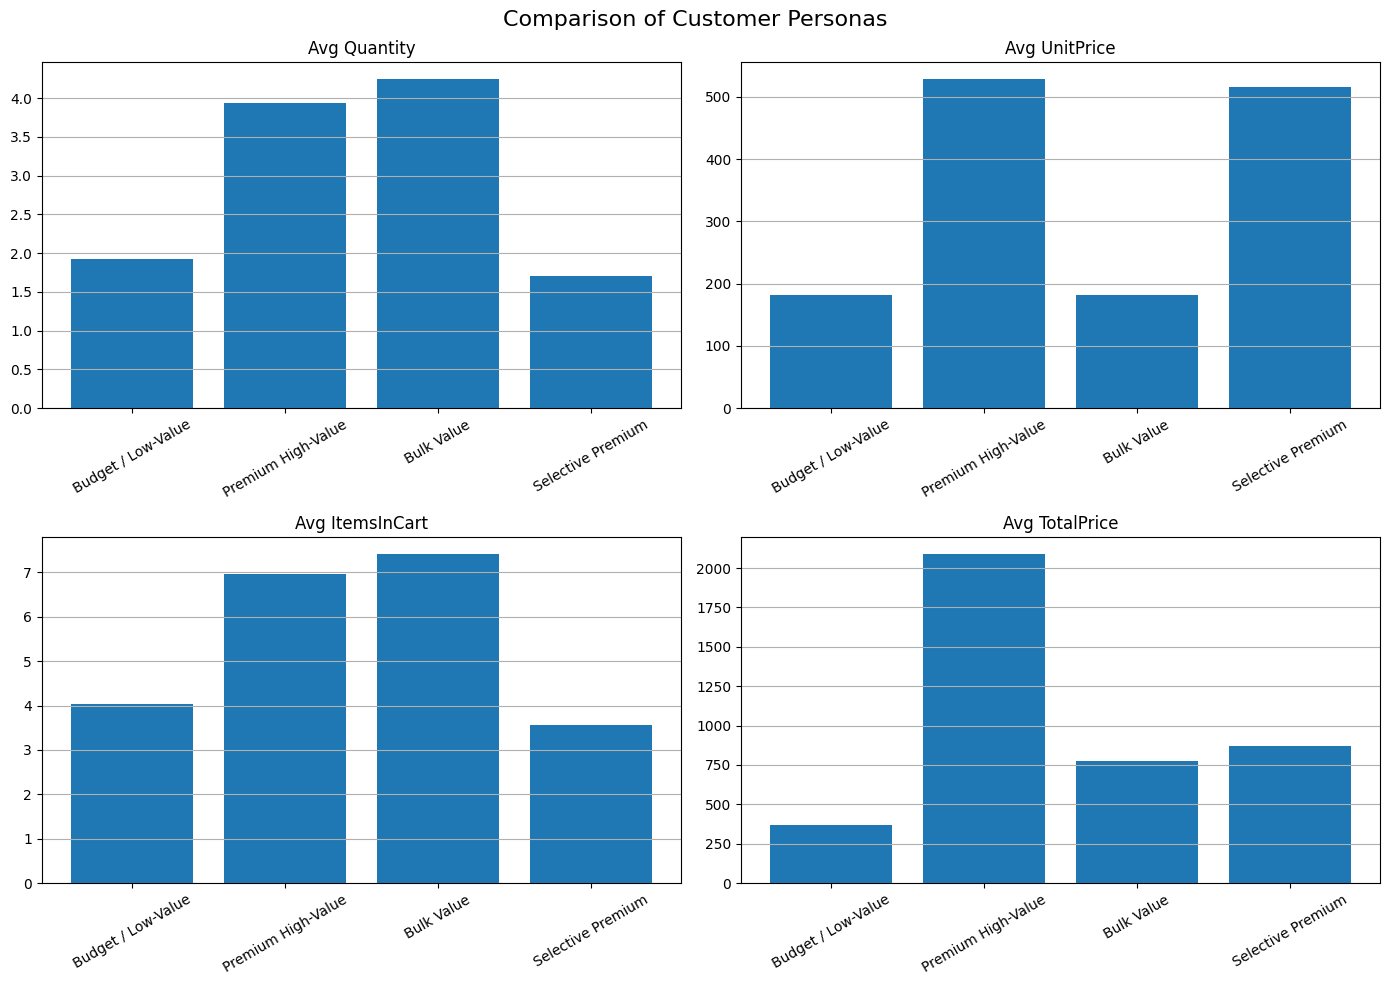

In [26]:
metrics = [
    'Avg_Quantity',
    'Avg_UnitPrice',
    'Avg_ItemsInCart',
    'Avg_TotalPrice'
]

persona_names = [
    'Budget / Low-Value',
    'Premium High-Value',
    'Bulk Value',
    'Selective Premium'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.flat, metrics):
    ax.bar(persona_names, persona_profile[metric])
    ax.set_title(metric.replace('_', ' '))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y')

plt.suptitle("Comparison of Customer Personas", fontsize=16)
plt.tight_layout()
plt.show()

## 28. Product Preferences Across Personas

Product preferences are compared across the four customer segments to identify differences in the types of products purchased.

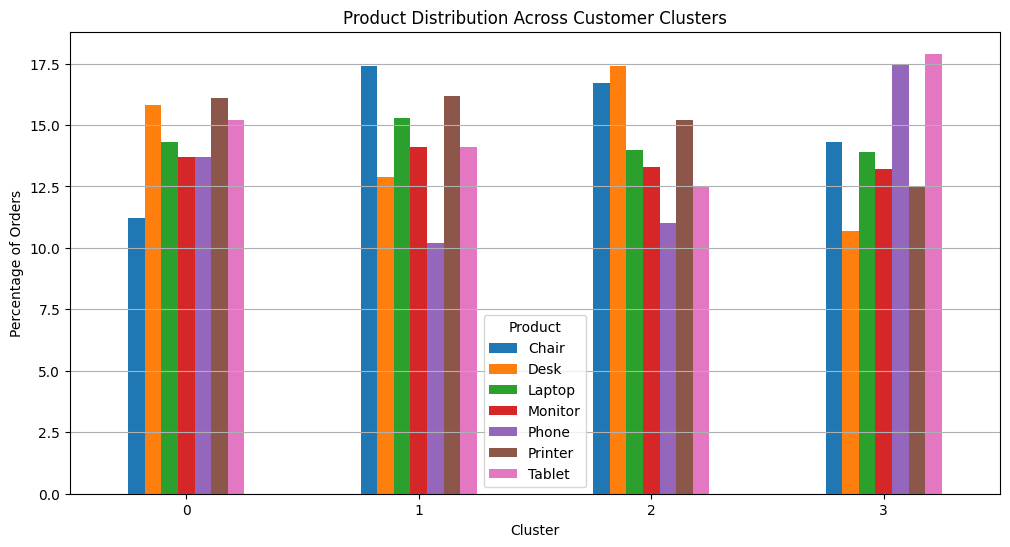

In [27]:
product_by_cluster.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage of Orders")
plt.title("Product Distribution Across Customer Clusters")
plt.xticks(rotation=0)
plt.legend(title="Product")
plt.grid(axis='y')

plt.show()

## 29. Coupon Behavior Across Personas

Coupon usage is compared across clusters to determine whether promotional behavior differs between customer segments.

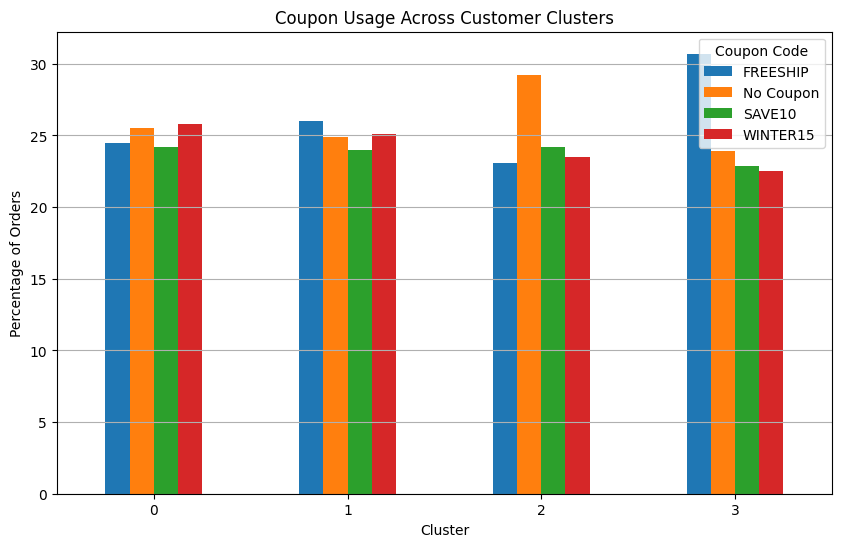

In [28]:
coupon_by_cluster.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage of Orders")
plt.title("Coupon Usage Across Customer Clusters")
plt.xticks(rotation=0)
plt.legend(title="Coupon Code")
plt.grid(axis='y')

plt.show()

## 30. Payment Preferences Across Personas

Payment method distributions are compared across the four customer segments.

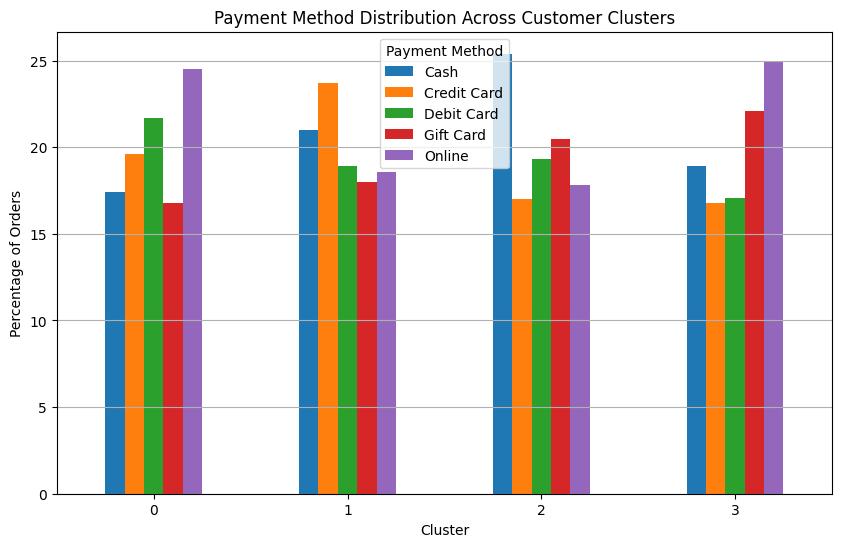

In [29]:
payment_by_cluster.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage of Orders")
plt.title("Payment Method Distribution Across Customer Clusters")
plt.xticks(rotation=0)
plt.legend(title="Payment Method")
plt.grid(axis='y')

plt.show()

## 31. Referral Sources Across Personas

Referral sources are analyzed to identify differences in the acquisition channels associated with each customer segment.

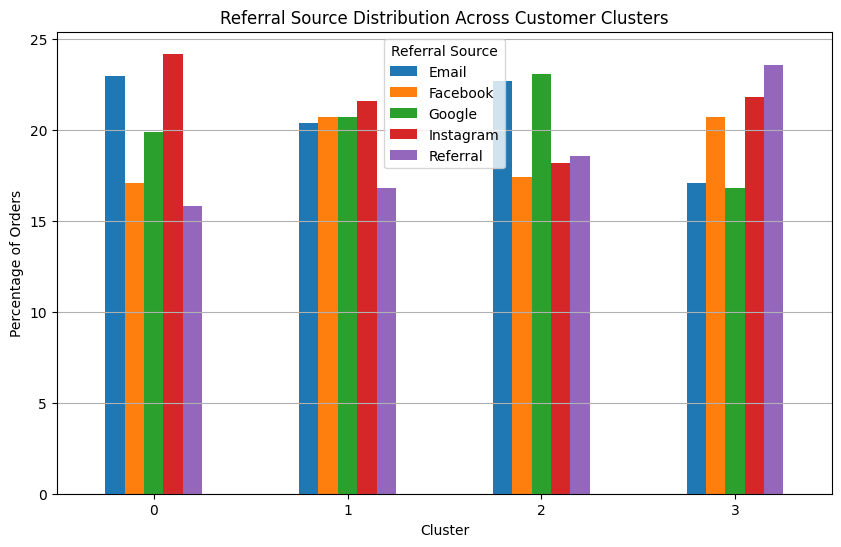

In [30]:
referral_by_cluster.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage of Orders")
plt.title("Referral Source Distribution Across Customer Clusters")
plt.xticks(rotation=0)
plt.legend(title="Referral Source")
plt.grid(axis='y')

plt.show()

## 32. Key Business Insights

The clustering analysis identified four distinct purchasing personas:

1. **Budget / Low-Value Shoppers**
   - Purchase fewer items.
   - Prefer lower-priced products.
   - Generate the lowest average order value.

2. **Premium High-Value Shoppers**
   - Purchase relatively expensive products.
   - Have larger baskets and higher quantities.
   - Generate the highest average spending.
   - Represent an important segment for retention and loyalty strategies.

3. **Bulk Value Shoppers**
   - Purchase the highest average quantity.
   - Have the largest average basket size.
   - Prefer relatively lower-priced products.
   - Are suitable targets for bundles and quantity-based promotions.

4. **Selective Premium Shoppers**
   - Purchase fewer items.
   - Choose relatively expensive products.
   - Have moderate-to-high transaction value despite smaller baskets.
   - Are suitable targets for premium recommendations and cross-selling.

Overall, the segmentation demonstrates that customers with similar spending levels do not necessarily have identical purchasing behavior. Some customers generate value through high-priced products, while others generate value through larger quantities and basket sizes.

## 33. Order Status Across Customer Personas

OrderStatus was excluded from the clustering features because it represents the outcome of an order rather than a primary purchasing characteristic.

After clustering, however, order status can be analyzed separately to determine whether different customer personas have different order outcomes.

In [31]:
status_by_cluster = pd.crosstab(
    df['Cluster'],
    df['OrderStatus'],
    normalize='index'
).round(3) * 100

status_by_cluster

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
Cluster,,,,,
0,21.7,19.6,18.3,22.0,18.3
1,21.6,21.0,20.7,19.2,17.7
2,20.8,19.3,20.5,18.6,20.8
3,18.9,16.8,19.6,22.5,22.1


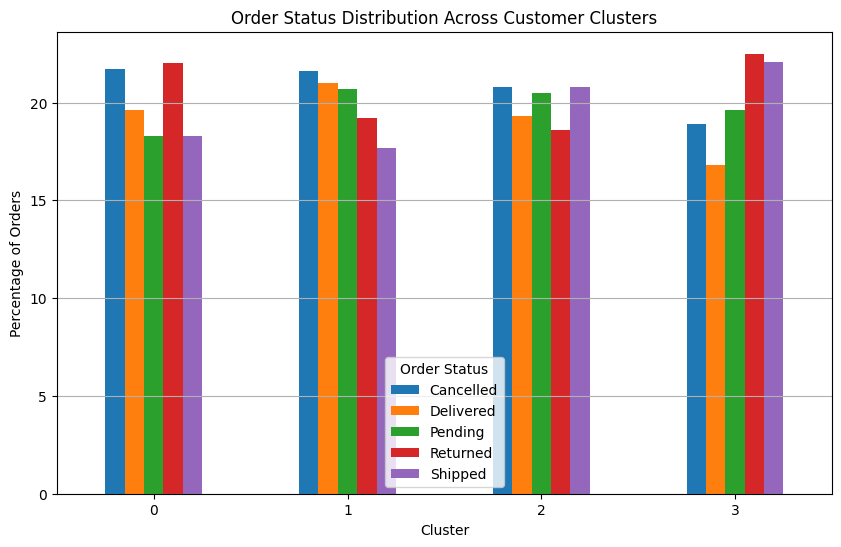

In [32]:
status_by_cluster.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage of Orders")
plt.title("Order Status Distribution Across Customer Clusters")
plt.xticks(rotation=0)
plt.legend(title="Order Status")
plt.grid(axis='y')

plt.show()

## 33. Order Status Analysis

OrderStatus was excluded from the clustering features because it represents an order outcome rather than a primary purchasing characteristic.

The distribution of order statuses across the four clusters is relatively similar. Although some differences can be observed, no cluster is overwhelmingly associated with a particular order status.

Therefore, OrderStatus does not substantially change the interpretation of the four customer personas and is retained as a supplementary business metric rather than a clustering feature.

## 34. Final PCA Cluster Visualization

The final K-Means segmentation is visualized in the two-dimensional PCA space.

Each observation is represented according to its first two principal components, while the X markers represent the centroids of the four clusters.

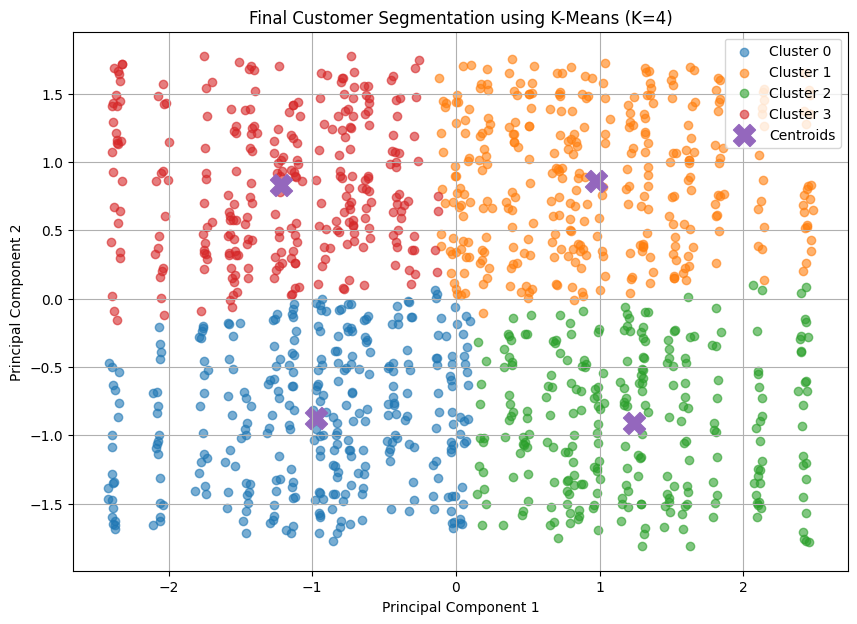

In [33]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = X_pca[df['Cluster'] == cluster]

    plt.scatter(
        cluster_data[:, 0],
        cluster_data[:, 1],
        alpha=0.6,
        label=f'Cluster {cluster}'
    )

plt.scatter(
    final_kmeans.cluster_centers_[:, 0],
    final_kmeans.cluster_centers_[:, 1],
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Final Customer Segmentation using K-Means (K=4)")
plt.legend()
plt.grid(True)

plt.show()

## 35. Final Cluster Summary

The final segmentation produces four distinct customer groups with different purchasing characteristics.

| Cluster | Persona | Key Characteristics |
|---|---|---|
| 0 | Budget / Low-Value Shoppers | Low quantity, low unit price, small basket and lowest spending |
| 1 | Premium High-Value Shoppers | High unit price, high quantity, large basket and highest spending |
| 2 | Bulk Value Shoppers | Highest quantity and basket size with relatively low unit price |
| 3 | Selective Premium Shoppers | Low quantity and basket size but relatively high unit price |

These differences demonstrate that customer value can arise from different purchasing patterns rather than from spending alone.

## 36. Business Recommendations

Based on the four customer personas, the following strategies can be recommended:

### 1. Budget / Low-Value Shoppers
- Promote affordable products and entry-level offerings.
- Use free-shipping or small discount incentives.
- Recommend complementary low-cost products to increase basket size.

### 2. Premium High-Value Shoppers
- Develop loyalty and VIP programs.
- Provide personalized premium-product recommendations.
- Focus on retention because this segment generates the highest average transaction value.

### 3. Bulk Value Shoppers
- Introduce quantity-based discounts.
- Promote product bundles and multi-item offers.
- Use cross-selling to increase the value of already large baskets.

### 4. Selective Premium Shoppers
- Emphasize product quality, features, and premium positioning.
- Provide detailed product comparisons and recommendations.
- Use cross-selling to encourage complementary purchases.

## 37. Limitations

There are several limitations to the current segmentation analysis:

1. The dataset contains 1,200 orders but only 1,189 unique customers, with most customers appearing only once. Therefore, the resulting segments primarily describe transaction-level purchasing behavior rather than long-term customer behavior.

2. The dataset contains 14 original columns. After categorical encoding, the feature matrix contains 24 dimensions, allowing PCA to be applied to the expanded numerical feature space.

3. The first three principal components explain approximately 48.5% of the total variance. Therefore, the two-dimensional PCA visualization represents only part of the original feature space.

4. K-Means assumes relatively well-defined numerical clusters and relies on distance measurements. The selected preprocessing and scaling steps were therefore important before clustering.

5. Customer lifetime value, purchase frequency over time, and historical customer behavior are limited because most customers occur only once in the supplied dataset.

## 38. Conclusion

This project applied an end-to-end unsupervised learning pipeline to retail transaction data for customer segmentation.

The data was first inspected and cleaned, including handling missing coupon information and removing identifiers and redundant features from the clustering process. Categorical variables were transformed using One-Hot Encoding, while numerical features were standardized.

Principal Component Analysis was then applied to reduce the 24-dimensional encoded feature space into a lower-dimensional representation. The first three principal components captured approximately 48.5% of the total variance.

K-Means clustering was evaluated using both the Elbow Method and Silhouette Score. The analysis identified **K = 4** as the most appropriate number of clusters because it provided the strongest Silhouette Score while also corresponding to the main elbow region of the inertia curve.

The four resulting customer personas were:

- **Budget / Low-Value Shoppers**
- **Premium High-Value Shoppers**
- **Bulk Value Shoppers**
- **Selective Premium Shoppers**

The analysis demonstrates that customers can exhibit substantially different purchasing behaviors even when they belong to the same overall retail population. These segments can therefore support targeted marketing, product recommendations, promotional strategies, and customer retention initiatives.

Overall, the project demonstrates how PCA and K-Means can be combined with business interpretation to transform unlabeled retail data into actionable customer insights.

## 39. Project Summary

### Techniques Used
- Data Cleaning
- Exploratory Data Analysis
- One-Hot Encoding
- Feature Scaling
- Principal Component Analysis (PCA)
- K-Means Clustering
- Elbow Method
- Silhouette Score
- Cluster Profiling
- Business Persona Development

### Final Model
**Algorithm:** K-Means Clustering  
**Optimal K:** 4  
**Dimensionality Reduction:** PCA  
**Number of Encoded Features:** 24  
**Number of Observations:** 1,200

### Final Personas
1. Budget / Low-Value Shoppers
2. Premium High-Value Shoppers
3. Bulk Value Shoppers
4. Selective Premium Shoppers